# Tiny Dreamer Highway — Iter 17: Combined Episode Length + Batch Size

**Name:** Esteban  
**Course:** CSC 580 AI 2  
**Assignment:** Final Project — Dream the Road  
**AI tools consulted:** GitHub Copilot

**Base:** iter5 + iter10 (steering_penalty=0.025)  
**Combined changes (Phase 3 winners):**
- Iter 13: `max_episode_steps: 75 → 120` (more diverse replay data)
- Iter 15: `batch_size: 256 → 384` (more diverse gradients)

**Hypothesis:** Iter 10 alone peaked at ~500 cycles then degraded (overfitting). Longer episodes feed more diverse transitions into the buffer; bigger batches sample more diverse transitions out. Together they should prevent the overfitting that killed iter 10 past 500 cycles.

## Iteration 17 — Anti-overfitting combo

Phase 3 isolated tests showed iters 13 and 15 were the best. Both improve data quality without changing rewards or model architecture. This combines them to test if the agent can train past 500 cycles without degrading.

In [9]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')
REPO_URL = 'https://github.com/estmon8u/CSC_580_Final_Project.git'
DRIVE_ROOT = Path('/content/drive/MyDrive/CSC_580_Final_Project')
ARTIFACT_ROOT = DRIVE_ROOT / 'artifacts'

for path in [DRIVE_ROOT, ARTIFACT_ROOT, ARTIFACT_ROOT / 'training_runs']:
    path.mkdir(parents=True, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%%bash
set -e
REPO_URL='https://github.com/estmon8u/CSC_580_Final_Project.git'
BRANCH='main'
if [ ! -d /content/CSC_580_Final_Project/.git ]; then
  git clone -b "${BRANCH}" "${REPO_URL}" /content/CSC_580_Final_Project
else
  cd /content/CSC_580_Final_Project
  git fetch origin "${BRANCH}"
  git checkout "${BRANCH}"
  git pull --ff-only origin "${BRANCH}"
fi
cd /content/CSC_580_Final_Project
python -m pip install --upgrade pip --quiet
python -m pip install -e . --quiet

Your branch is up to date with 'origin/GrandpaDrivers'.
Already up to date.


From https://github.com/estmon8u/CSC_580_Final_Project
 * branch            GrandpaDrivers -> FETCH_HEAD
Already on 'GrandpaDrivers'
From https://github.com/estmon8u/CSC_580_Final_Project
 * branch            GrandpaDrivers -> FETCH_HEAD


In [11]:
import json
import sys
import torch
from pathlib import Path

PROJECT_ROOT = Path('/content/CSC_580_Final_Project')
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from tiny_dreamer_highway.config import load_experiment_config
from tiny_dreamer_highway.training import run_training_experiment

CONFIG_PATH = PROJECT_ROOT / 'notebooks' / 'configs' / 'training_run.yaml'
config = load_experiment_config(CONFIG_PATH)

print(json.dumps(config.model_dump(), indent=2))

gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none'
print('Loaded config from:', CONFIG_PATH)
print('GPU:', gpu_name)

# --- Iter5 base + Iter10 winner (current best config) ---
config.env.action.smoothing_factor = 0.5
config.env.vehicles_count = 12
config.env.npc_speed_scale = 0.65
config.env.reward.normalize_reward = False
config.env.frame_stack = 3
config.env.reward.steering_penalty = 0.025

print('\nBase overrides (iter5 + iter10):')
print(f'  smoothing_factor = {config.env.action.smoothing_factor}')
print(f'  vehicles_count = {config.env.vehicles_count}')
print(f'  npc_speed_scale = {config.env.npc_speed_scale}')
print(f'  normalize_reward = {config.env.reward.normalize_reward}')
print(f'  frame_stack = {config.env.frame_stack}')
print(f'  steering_penalty = {config.env.reward.steering_penalty}')

# --- Iter 17 Combined Overrides (Phase 3 winners) ---
# Iter 13: max_episode_steps 75 -> 120: longer episodes for more diverse data
config.env.max_episode_steps = 120
# Iter 15: batch_size 256 -> 384: more diverse transitions per update
config.training.batch_size = 384

print('\nIter 17 combined overrides:')
print(f'  max_episode_steps = {config.env.max_episode_steps}')
print(f'  batch_size = {config.training.batch_size}')

{
  "seed": 7,
  "device": "cuda",
  "env": {
    "env_id": "highway-v0",
    "observation_height": 64,
    "observation_width": 64,
    "frame_stack": 1,
    "max_episode_steps": 75,
    "lanes_count": 4,
    "vehicles_count": 28,
    "npc_speed_scale": 0.85,
    "simulation_frequency": 15,
    "policy_frequency": 5,
    "action": {
      "type": "continuous",
      "longitudinal": true,
      "lateral": true,
      "longitudinal_scale": 0.7,
      "lateral_scale": 0.35,
      "smoothing_factor": 0.6,
      "num_actions": 5
    },
    "reward": {
      "collision_reward": -1.0,
      "right_lane_reward": 0.0,
      "high_speed_reward": 0.8,
      "lane_change_reward": 0.0,
      "overtake_reward": 2.5,
      "normalize_reward": true,
      "reward_speed_range": [
        26.0,
        35.0
      ],
      "offroad_terminal": true,
      "offroad_penalty": 0.5,
      "steering_penalty": 0.0075,
      "steering_change_penalty": 0.02
    }
  },
  "replay": {
    "capacity": 500000,
    "s

In [12]:
RUN_NAME = 'iter17_episode_batch'
RUN_ARTIFACT_ROOT = ARTIFACT_ROOT / 'training_runs' / RUN_NAME
RUN_ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

CYCLES = 1000
WARM_START_STEPS = None
POLICY_STEPS = None
CHECKPOINT_INTERVAL = None
RESUME_FROM = '/content/drive/MyDrive/CSC_580_Final_Project/artifacts/training_runs/' + RUN_NAME + '/checkpoints/checkpoint_00500.pt'

print('Run name:', RUN_NAME)
print('Resume from:', RESUME_FROM if RESUME_FROM else '(fresh run — old artifacts will be cleared)')
print('Effective cycles:', config.training.cycles if CYCLES is None else CYCLES)
print('Effective policy steps:', config.training.policy_steps if POLICY_STEPS is None else POLICY_STEPS)

Run name: iter17_episode_batch
Resume from: /content/drive/MyDrive/CSC_580_Final_Project/artifacts/training_runs/iter17_episode_batch/checkpoints/checkpoint_00500.pt
Effective cycles: 1000
Effective policy steps: 32


In [13]:
print('Launching baseline real run. Per-cycle progress lines will appear below.')

training_summary = run_training_experiment(
    config,
    RUN_ARTIFACT_ROOT,
    cycles=CYCLES,
    warm_start_steps=WARM_START_STEPS,
    policy_steps=POLICY_STEPS,
    checkpoint_interval=CHECKPOINT_INTERVAL,
    resume_from=RESUME_FROM,
)

print('Completed cycles:', training_summary.completed_cycles)
print('Latest checkpoint:', training_summary.latest_checkpoint)
print('Latest metrics:', training_summary.latest_record)

Launching baseline real run. Per-cycle progress lines will appear below.
[train] starting run | cycles=1000 | start_step=501 | warm_start_steps=10000 | policy_steps=32 | device=cuda
[train] step=501/1000 | warm=0 | policy=32 | replay=15352 | world_total=11307.2703 | actor=-29.0312 | critic=2.0982 | eval_reward=n/a | cycle_s=4.2 | elapsed_s=4.2 | checkpoint=-
[train] step=502/1000 | warm=0 | policy=32 | replay=15384 | world_total=11315.4553 | actor=-31.0469 | critic=3.8332 | eval_reward=n/a | cycle_s=5.5 | elapsed_s=9.7 | checkpoint=-
[train] step=503/1000 | warm=0 | policy=32 | replay=15416 | world_total=11310.0673 | actor=-30.4688 | critic=3.3110 | eval_reward=n/a | cycle_s=6.5 | elapsed_s=16.3 | checkpoint=-
[train] step=504/1000 | warm=0 | policy=32 | replay=15448 | world_total=11308.5930 | actor=-30.7188 | critic=2.3099 | eval_reward=n/a | cycle_s=7.5 | elapsed_s=23.8 | checkpoint=-
[train] step=505/1000 | warm=0 | policy=32 | replay=15480 | world_total=11307.8259 | actor=-29.2969 

In [14]:
summary_path = training_summary.log_dir / 'latest_summary.json'
summary_payload = json.loads(summary_path.read_text(encoding='utf-8'))
summary_payload

{'checkpoint_file': '/content/drive/MyDrive/CSC_580_Final_Project/artifacts/training_runs/iter17_episode_batch/checkpoints/checkpoint_01000.pt',
 'latest_metrics': {'behavior/actor_loss': -2.642578125,
  'behavior/critic_loss': 1.9995644986629486,
  'behavior/imagined_reward_mean': 0.090087890625,
  'behavior/imagined_value_mean': 2.5546875,
  'evaluation/crash_rate': 1.0,
  'evaluation/episodes': 10.0,
  'evaluation/mean_reward': -0.008491298479959386,
  'evaluation/mean_steps': 10.1,
  'policy_added': 32,
  'replay_size': 31320,
  'step': 1000,
  'warm_start_added': 0,
  'world_model/continue_loss': 0.0013830763346049935,
  'world_model/kl_loss': 3.4749657213687897,
  'world_model/kl_loss_raw': 3.4749657213687897,
  'world_model/observation_log_prob': -11304.352905273438,
  'world_model/overshooting_feature_mse': 0.017334935255348682,
  'world_model/overshooting_kl_loss': 4.609856367111206,
  'world_model/overshooting_pairs': 65.0,
  'world_model/reconstruction_loss': 11304.352905273

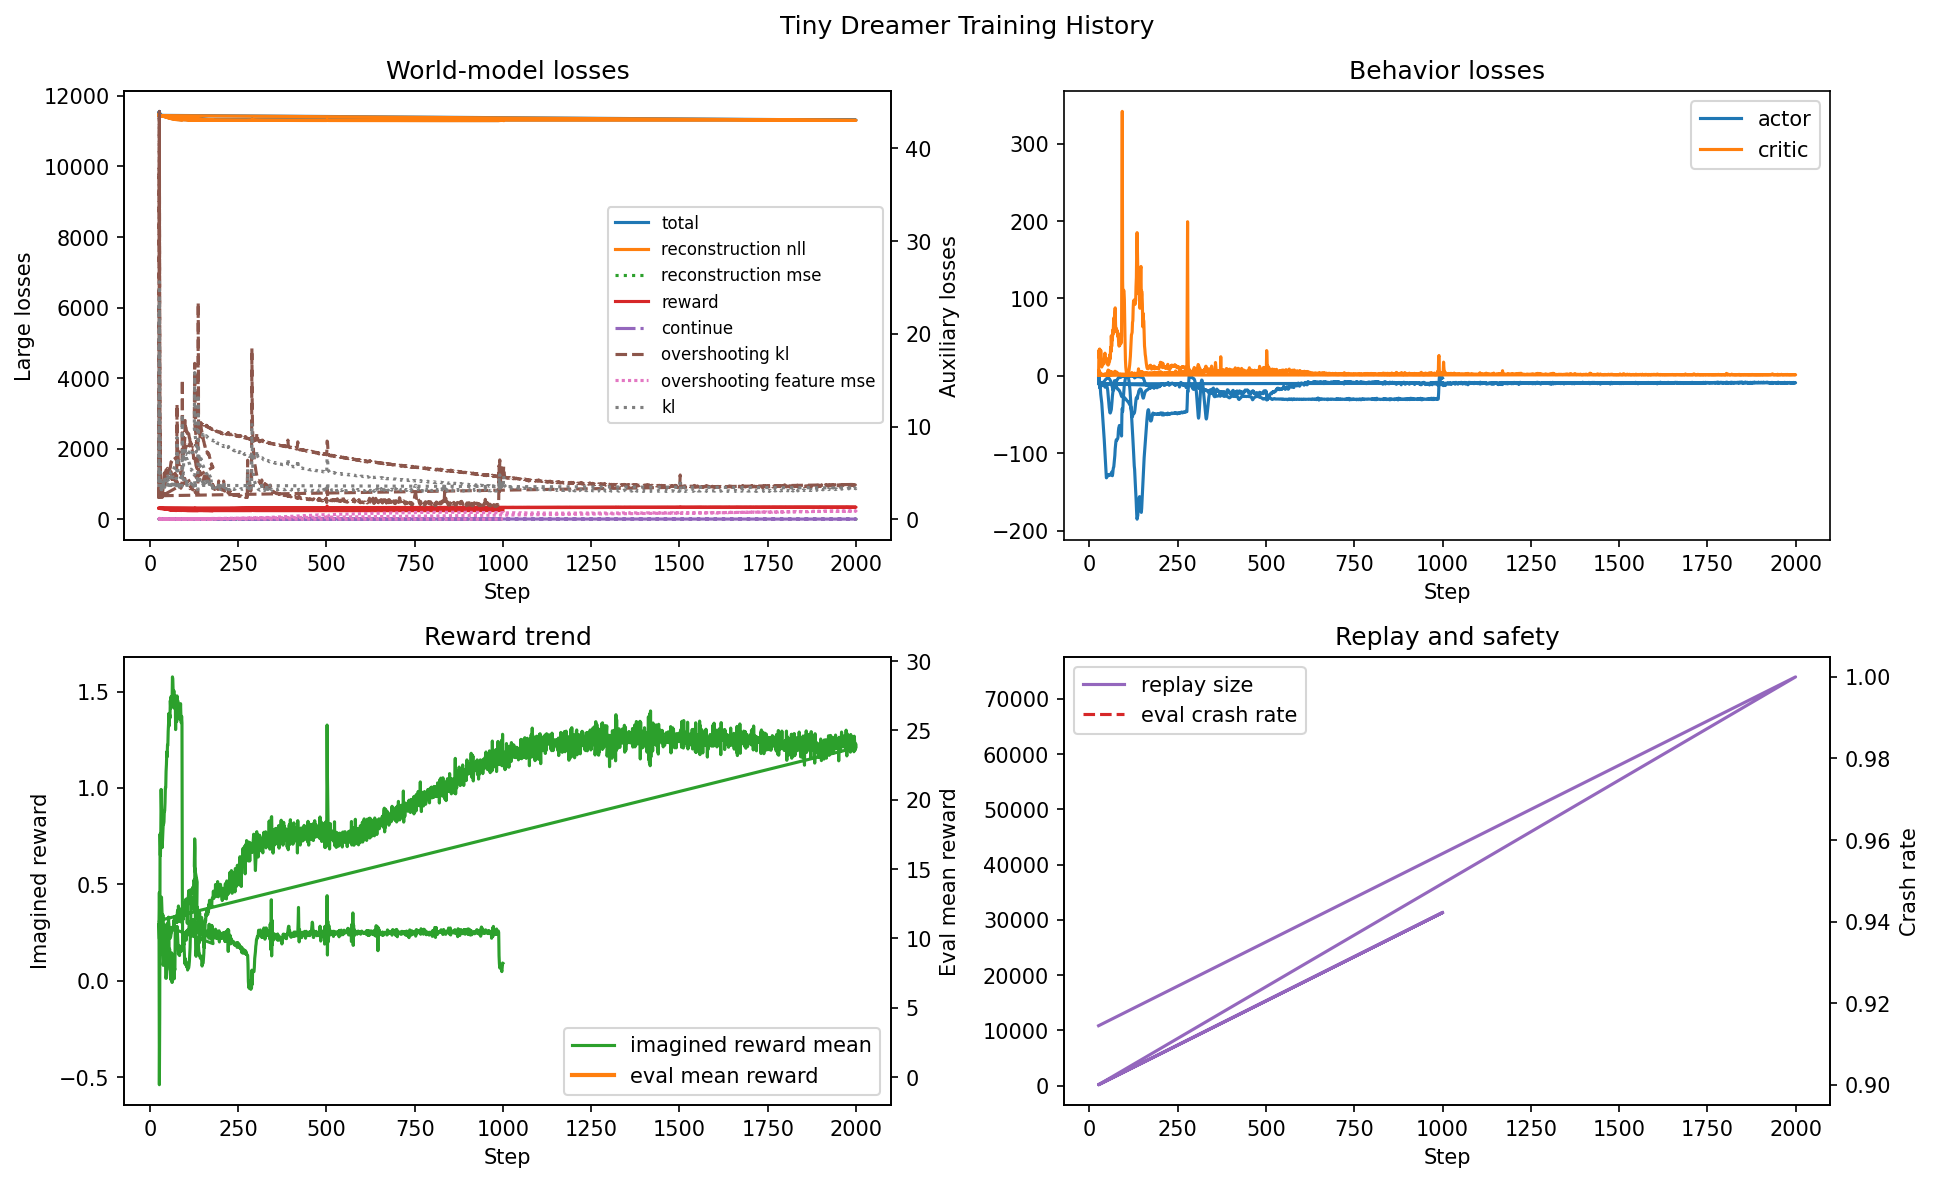

{'analysis_summary': {'best_eval_mean_reward': 28.858811880950647,
  'best_eval_reward_step': 1050,
  'best_imagined_reward_mean': 1.576171875,
  'best_imagined_reward_step': 64,
  'best_world_model_step': 983,
  'best_world_model_total_loss': 11302.097778320312,
  'largest_replay_size': 74000,
  'largest_replay_step': 2000,
  'last_metrics': {'behavior/actor_loss': -2.642578125,
   'behavior/critic_loss': 1.9995644986629486,
   'behavior/imagined_reward_mean': 0.090087890625,
   'behavior/imagined_value_mean': 2.5546875,
   'evaluation/crash_rate': 1.0,
   'evaluation/episodes': 10.0,
   'evaluation/mean_reward': -0.008491298479959386,
   'evaluation/mean_steps': 10.1,
   'policy_added': 32,
   'replay_size': 31320,
   'step': 1000,
   'warm_start_added': 0,
   'world_model/continue_loss': 0.0013830763346049935,
   'world_model/kl_loss': 3.4749657213687897,
   'world_model/kl_loss_raw': 3.4749657213687897,
   'world_model/observation_log_prob': -11304.352905273438,
   'world_model/ove

In [15]:
from IPython.display import Image, display
import csv
import importlib
import json
import tiny_dreamer_highway.evaluation.training_analysis as training_analysis

training_analysis = importlib.reload(training_analysis)
export_training_history_artifacts = training_analysis.export_training_history_artifacts

analysis_outputs = export_training_history_artifacts(
    training_summary.log_dir / 'cycle_metrics.csv',
    RUN_ARTIFACT_ROOT / 'analysis',
    prefix=RUN_NAME,
)

display(Image(filename=str(analysis_outputs['curves'])))
analysis_summary = json.loads(analysis_outputs['summary'].read_text(encoding='utf-8'))
with (training_summary.log_dir / 'cycle_metrics.csv').open('r', encoding='utf-8', newline='') as handle:
    metric_rows = list(csv.DictReader(handle))
latest_metrics_row = metric_rows[-1]
{
    'analysis_summary': analysis_summary,
    'phase4_metrics': {
        'world_model/reconstruction_loss': latest_metrics_row.get('world_model/reconstruction_loss'),
        'world_model/reconstruction_mse': latest_metrics_row.get('world_model/reconstruction_mse'),
        'world_model/observation_log_prob': latest_metrics_row.get('world_model/observation_log_prob'),
        'world_model/overshooting_kl_loss': latest_metrics_row.get('world_model/overshooting_kl_loss'),
        'world_model/overshooting_feature_mse': latest_metrics_row.get('world_model/overshooting_feature_mse'),
        'evaluation/mean_reward': latest_metrics_row.get('evaluation/mean_reward'),
        'evaluation/crash_rate': latest_metrics_row.get('evaluation/crash_rate'),
    },
}

## Agent Driving Demo

Record agent-driving GIFs using the trained policy from this run. These show the actor driving in the real highway-env.

Using demo recorder from: tiny_dreamer_highway.evaluation.policy_rollout
[demo] episode 1/10 | steps=4 | reward=-0.52 | CRASH | saved iter17_episode_batch_ep01.gif
[demo] episode 2/10 | steps=10 | reward=-0.56 | CRASH | saved iter17_episode_batch_ep02.gif
[demo] episode 3/10 | steps=5 | reward=-0.53 | CRASH | saved iter17_episode_batch_ep03.gif
[demo] episode 4/10 | steps=16 | reward=1.90 | CRASH | saved iter17_episode_batch_ep04.gif
[demo] episode 5/10 | steps=19 | reward=1.89 | CRASH | saved iter17_episode_batch_ep05.gif
[demo] episode 6/10 | steps=8 | reward=-0.54 | CRASH | saved iter17_episode_batch_ep06.gif
[demo] episode 7/10 | steps=12 | reward=-1.07 | CRASH | saved iter17_episode_batch_ep07.gif
[demo] episode 8/10 | steps=7 | reward=-1.04 | CRASH | saved iter17_episode_batch_ep08.gif
[demo] episode 9/10 | steps=20 | reward=1.87 | CRASH | saved iter17_episode_batch_ep09.gif
[demo] episode 10/10 | steps=7 | reward=-1.04 | CRASH | saved iter17_episode_batch_ep10.gif
[demo] done | 

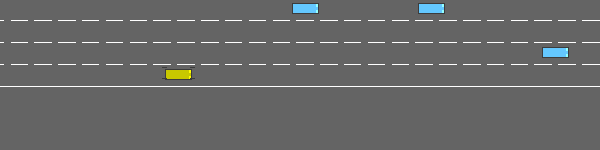


iter17_episode_batch_ep02.gif


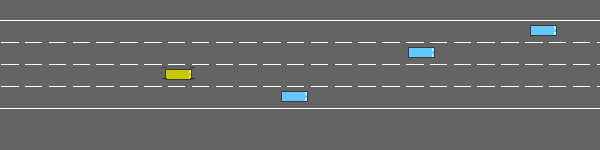


iter17_episode_batch_ep03.gif


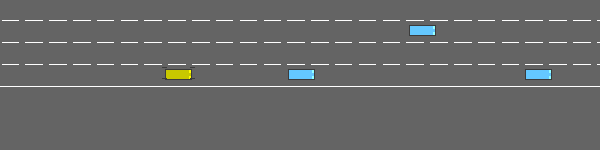


iter17_episode_batch_ep04.gif


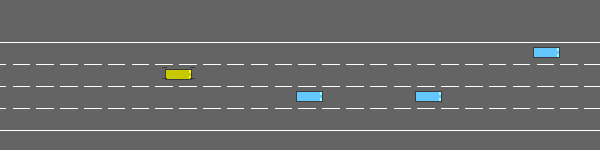


iter17_episode_batch_ep05.gif


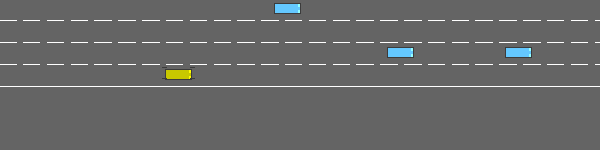


iter17_episode_batch_ep06.gif


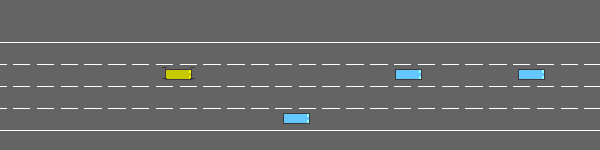


iter17_episode_batch_ep07.gif


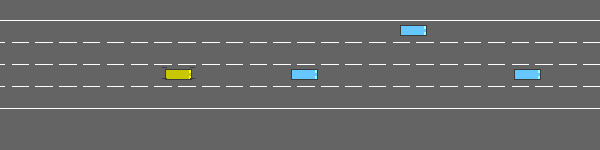


iter17_episode_batch_ep08.gif


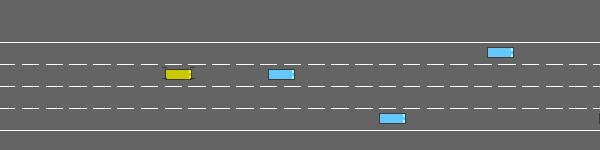


iter17_episode_batch_ep09.gif


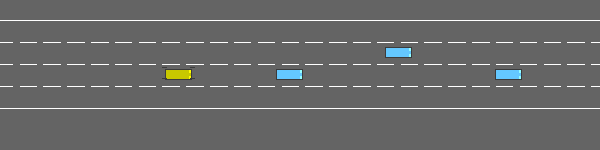


iter17_episode_batch_ep10.gif


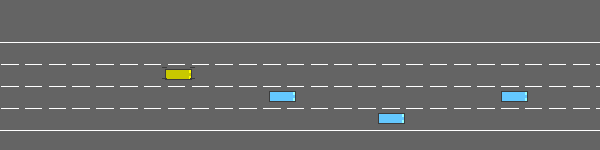

In [16]:
from IPython.display import Image, display
import importlib
import tiny_dreamer_highway.evaluation as evaluation_pkg

try:
    evaluation_pkg = importlib.reload(evaluation_pkg)
    record_demo_videos = evaluation_pkg.record_demo_videos
except (AttributeError, ImportError):
    from tiny_dreamer_highway.evaluation.policy_rollout import record_demo_videos

print('Using demo recorder from:', record_demo_videos.__module__)

demo_outputs = record_demo_videos(
    config,
    checkpoint_path=training_summary.latest_checkpoint,
    output_dir=RUN_ARTIFACT_ROOT / 'demo_videos',
    num_episodes=10,
    max_steps=1000,
    fps=15,
    seed=132,
    prefix=RUN_NAME,
    device=config.device,
)

for gif_path in demo_outputs.video_paths:
    print(f'\n{gif_path.name}')
    display(Image(filename=str(gif_path)))